# Indicator Validation: `indicators/` vs the `ta` library

One cell per indicator. Every plot uses **real** MES=F 1-minute futures data pulled directly from `duckdb/futures_data.duckdb` -- no synthetic data anywhere in this notebook.

For each indicator:
- **solid line** = our implementation (`indicators/`)
- **dashed line** = the `ta` library's implementation (or an independent from-scratch reference, for the handful of indicators `ta` doesn't provide -- supertrend, choppiness index, wilder_average, and the simple derived helpers)

See `tests/test_indicators_vs_ta.py` for the numeric tolerances behind each comparison -- this notebook is the visual companion to that test file, not a replacement for it.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from ta.momentum import ROCIndicator, RSIIndicator, StochasticOscillator
from ta.trend import ADXIndicator, AroonIndicator, EMAIndicator, MACD as TAMACD, PSARIndicator, SMAIndicator, WMAIndicator
from ta.volatility import AverageTrueRange, BollingerBands, DonchianChannel, KeltnerChannel

from indicators import (
    adx, aroon, atr, bollinger_bands, choppiness_index, distance_from_high,
    donchian_channels, drawdown_from_rolling_high, dual_donchian_channels, ema,
    keltner_channels, macd, moving_average_crossover, parabolic_sar,
    recovery_moving_average, roc, rolling_high, rolling_low, rolling_volatility,
    rsi, sma, stochastic_oscillator, supertrend, true_range, wilder_average, wma,
)

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("Setup OK")

Setup OK


## Load real data

Pulls the most recent bars for **MES=F** (Micro E-mini S&P 500) straight from `duckdb/futures_data.duckdb`. Indicators are computed over the full pulled window (so slow-period indicators like a 200-period MA are fully warmed up), but charts only show the last `PLOT_BARS` of it so the lines are actually readable.

In [2]:
FUTURES_DB_PATH = PROJECT_ROOT / "duckdb" / "futures_data.duckdb"
SYMBOL = "MES=F"
COMPUTE_BARS = 6000   # history pulled for indicator warmup
PLOT_BARS = 1500      # window actually shown on each chart

connection = duckdb.connect(str(FUTURES_DB_PATH), read_only=True)
raw = connection.execute(
    """
    SELECT timestamp, open, high, low, close, volume
    FROM bars
    WHERE symbol = ?
    ORDER BY timestamp DESC
    LIMIT ?
    """,
    [SYMBOL, COMPUTE_BARS],
).fetchdf()
connection.close()

ohlc = raw.sort_values("timestamp").set_index("timestamp")[["open", "high", "low", "close", "volume"]]

print(f"{SYMBOL}: {len(ohlc):,} bars, {ohlc.index[0]} -> {ohlc.index[-1]}")
ohlc.tail()

MES=F: 6,000 bars, 2026-03-09 13:00:00 -> 2026-03-13 20:59:00


,open,high,low,close,volume
timestamp,,,,,
2026-03-13 20:55:00,6629.00,6629.00,6625.00,6626.00,1018.0
2026-03-13 20:56:00,6626.25,6626.25,6625.25,6625.75,336.0
2026-03-13 20:57:00,6626.00,6627.00,6625.50,6626.25,183.0
2026-03-13 20:58:00,6626.25,6627.00,6626.00,6626.00,383.0
2026-03-13 20:59:00,6626.25,6626.75,6625.00,6625.25,493.0


In [3]:
def plot_compare(title: str, price: pd.Series | None = None, window: int = PLOT_BARS, **series: pd.Series) -> None:
    """Plot our indicator(s) vs ta/reference indicator(s) over the last `window` bars.

    Series names starting with "ta_" or "ref_" are drawn dashed; everything
    else ("ours_...") is drawn solid. Pass price=ohlc["close"] to show the
    close price faintly in the background for context.
    """
    fig, ax = plt.subplots()

    if price is not None:
        windowed_price = price.iloc[-window:]
        ax.plot(windowed_price.index, windowed_price.to_numpy(), color="lightgray", linewidth=1.0, label="close", zorder=1)

    for name, values in series.items():
        windowed = values.iloc[-window:]
        is_reference = name.startswith("ta_") or name.startswith("ref_")
        ax.plot(
            windowed.index,
            windowed.to_numpy(),
            linestyle="--" if is_reference else "-",
            linewidth=1.6 if not is_reference else 1.3,
            label=name,
            zorder=3 if not is_reference else 2,
        )

    ax.set_title(title)
    ax.legend(loc="best", fontsize=8, ncol=2)
    fig.tight_layout()
    plt.show()

## Moving averages

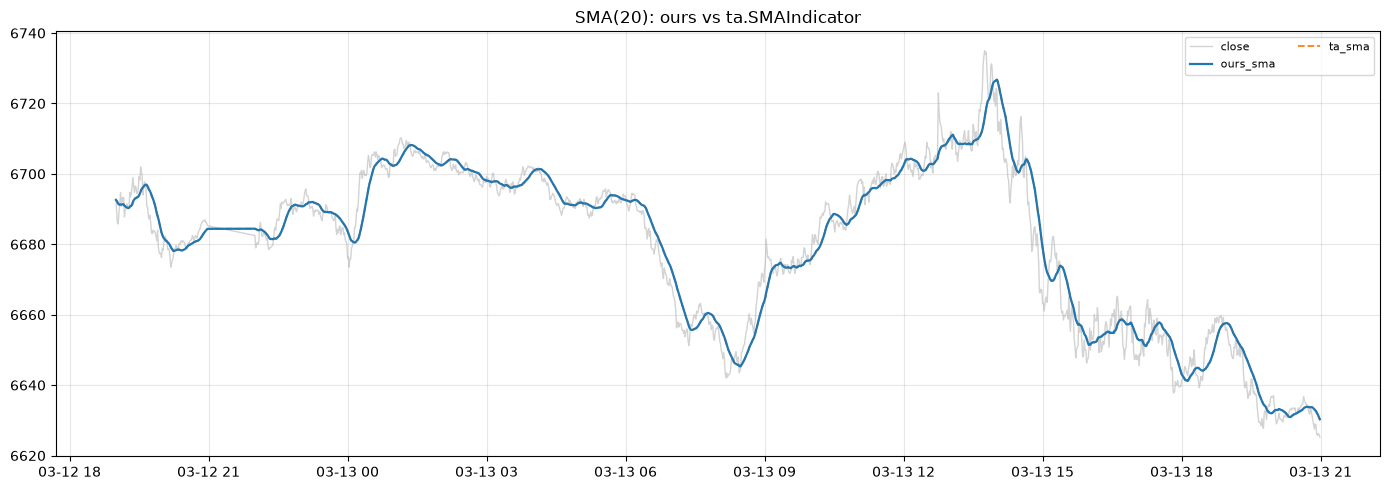

In [4]:
# SMA(20)
ours_sma = sma(ohlc["close"], period=20)
ta_sma = SMAIndicator(ohlc["close"], window=20).sma_indicator()

plot_compare("SMA(20): ours vs ta.SMAIndicator", price=ohlc["close"], ours_sma=ours_sma, ta_sma=ta_sma)

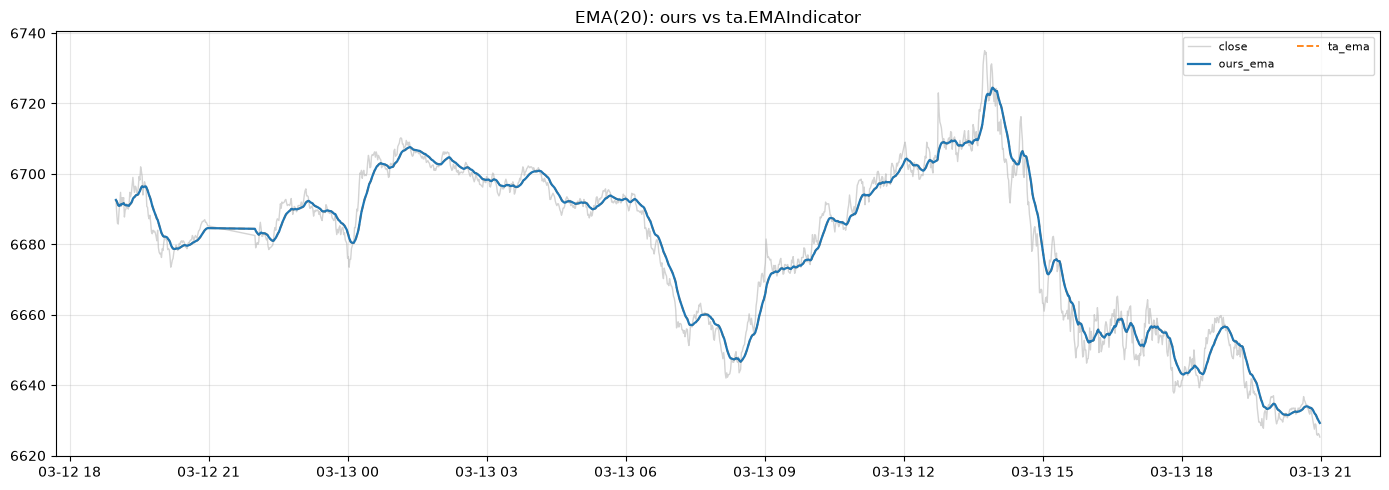

In [5]:
# EMA(20)
ours_ema = ema(ohlc["close"], period=20)
ta_ema = EMAIndicator(ohlc["close"], window=20).ema_indicator()

plot_compare("EMA(20): ours vs ta.EMAIndicator", price=ohlc["close"], ours_ema=ours_ema, ta_ema=ta_ema)

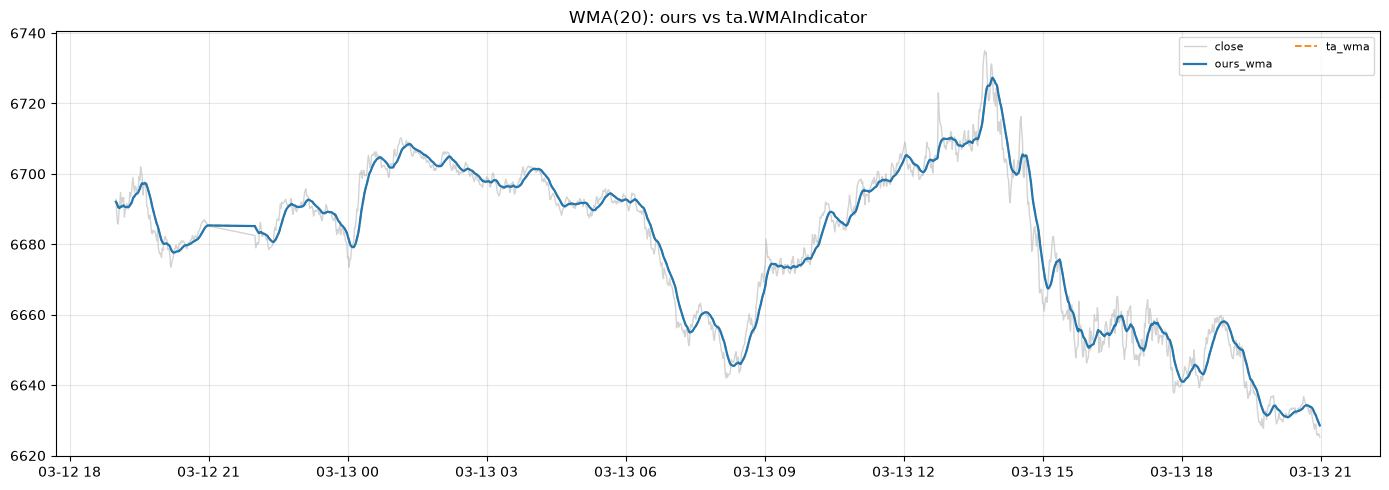

In [6]:
# WMA(20)
ours_wma = wma(ohlc["close"], period=20)
ta_wma = WMAIndicator(ohlc["close"], window=20).wma()

plot_compare("WMA(20): ours vs ta.WMAIndicator", price=ohlc["close"], ours_wma=ours_wma, ta_wma=ta_wma)

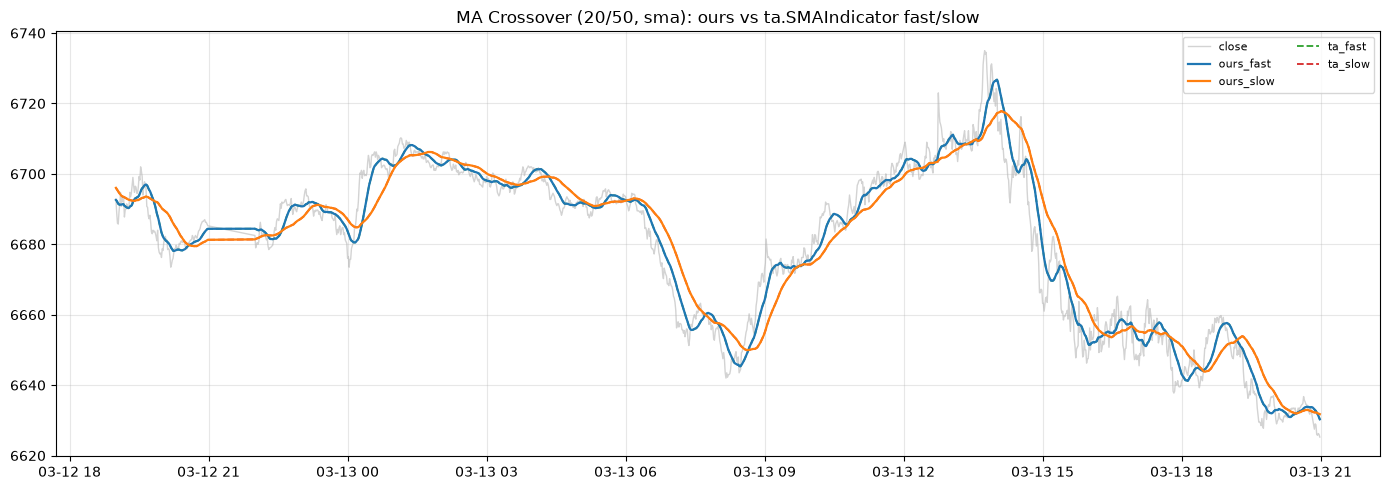

In [7]:
# Moving average crossover (fast=20, slow=50, sma) -- ta has no dedicated
# crossover indicator, so the "ta" side is built from ta.trend.SMAIndicator
# directly at the same fast/slow periods.
crossover = moving_average_crossover(ohlc["close"], fast_period=20, slow_period=50, method="sma")
ta_fast = SMAIndicator(ohlc["close"], window=20).sma_indicator()
ta_slow = SMAIndicator(ohlc["close"], window=50).sma_indicator()

plot_compare(
    "MA Crossover (20/50, sma): ours vs ta.SMAIndicator fast/slow",
    price=ohlc["close"],
    ours_fast=crossover["fast_ma"],
    ours_slow=crossover["slow_ma"],
    ta_fast=ta_fast,
    ta_slow=ta_slow,
)

## Momentum

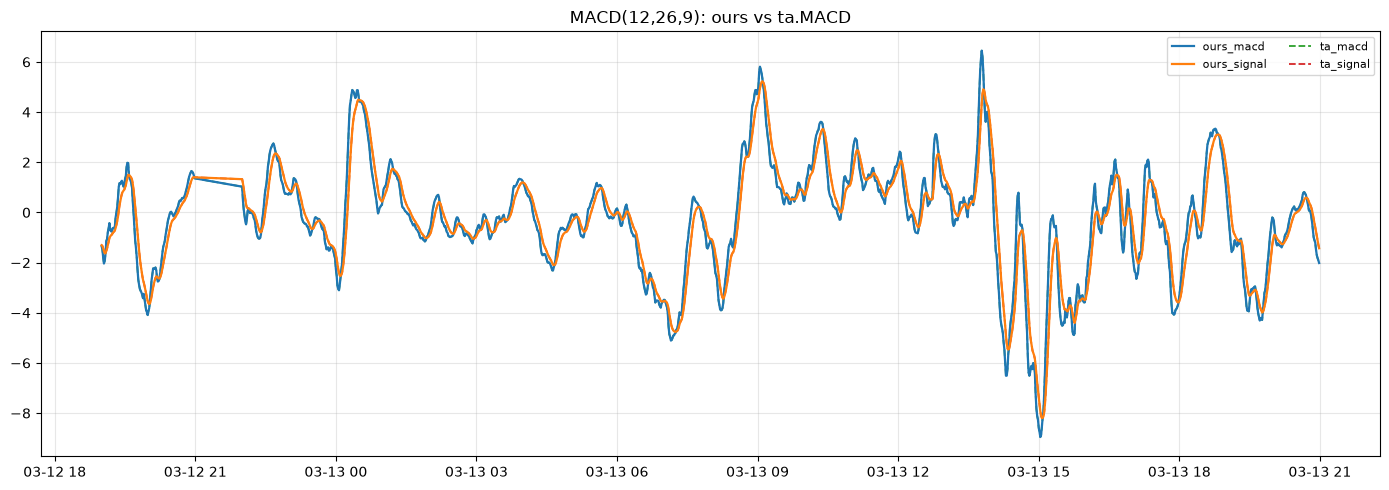

In [8]:
# MACD (12/26/9)
ours_macd = macd(ohlc["close"], fast_period=12, slow_period=26, signal_period=9)
ta_macd = TAMACD(ohlc["close"], window_fast=12, window_slow=26, window_sign=9)

plot_compare(
    "MACD(12,26,9): ours vs ta.MACD",
    ours_macd=ours_macd["macd"],
    ours_signal=ours_macd["signal"],
    ta_macd=ta_macd.macd(),
    ta_signal=ta_macd.macd_signal(),
)

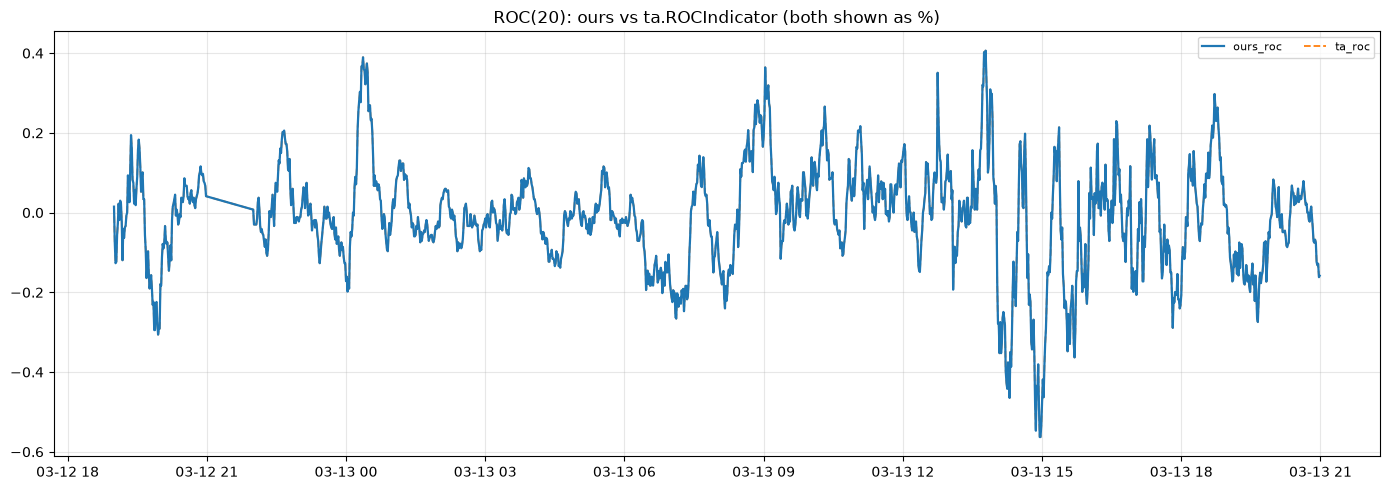

In [9]:
# ROC(20) -- ta reports a percentage (5.0), ours reports a fraction (0.05)
ours_roc = roc(ohlc["close"], period=20) * 100.0
ta_roc = ROCIndicator(ohlc["close"], window=20).roc()

plot_compare("ROC(20): ours vs ta.ROCIndicator (both shown as %)", ours_roc=ours_roc, ta_roc=ta_roc)

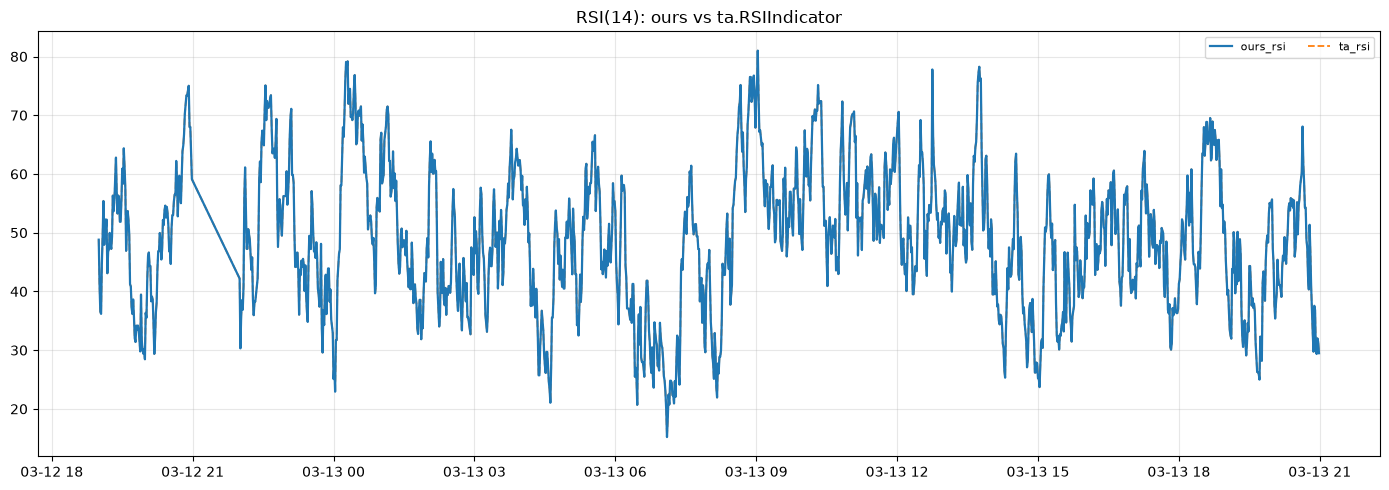

In [10]:
# RSI(14) -- both use ewm(alpha=1/period, adjust=False), but they seed the
# recursion slightly differently at bar 0, so expect a small, decaying gap
# near the left edge of the window rather than a perfect overlay throughout.
ours_rsi = rsi(ohlc["close"], period=14)
ta_rsi = RSIIndicator(ohlc["close"], window=14).rsi()

plot_compare("RSI(14): ours vs ta.RSIIndicator", ours_rsi=ours_rsi, ta_rsi=ta_rsi)

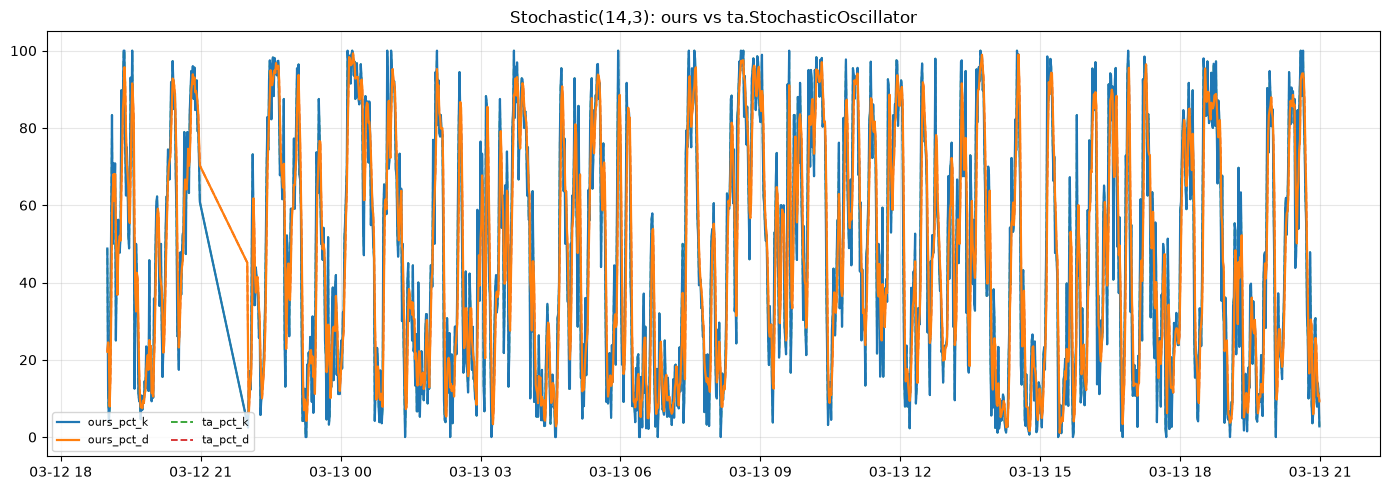

In [11]:
# Stochastic Oscillator (14, 3)
ours_stoch = stochastic_oscillator(ohlc, k_period=14, d_period=3)
ta_stoch = StochasticOscillator(high=ohlc["high"], low=ohlc["low"], close=ohlc["close"], window=14, smooth_window=3)

plot_compare(
    "Stochastic(14,3): ours vs ta.StochasticOscillator",
    ours_pct_k=ours_stoch["percent_k"],
    ours_pct_d=ours_stoch["percent_d"],
    ta_pct_k=ta_stoch.stoch(),
    ta_pct_d=ta_stoch.stoch_signal(),
)

## Volatility

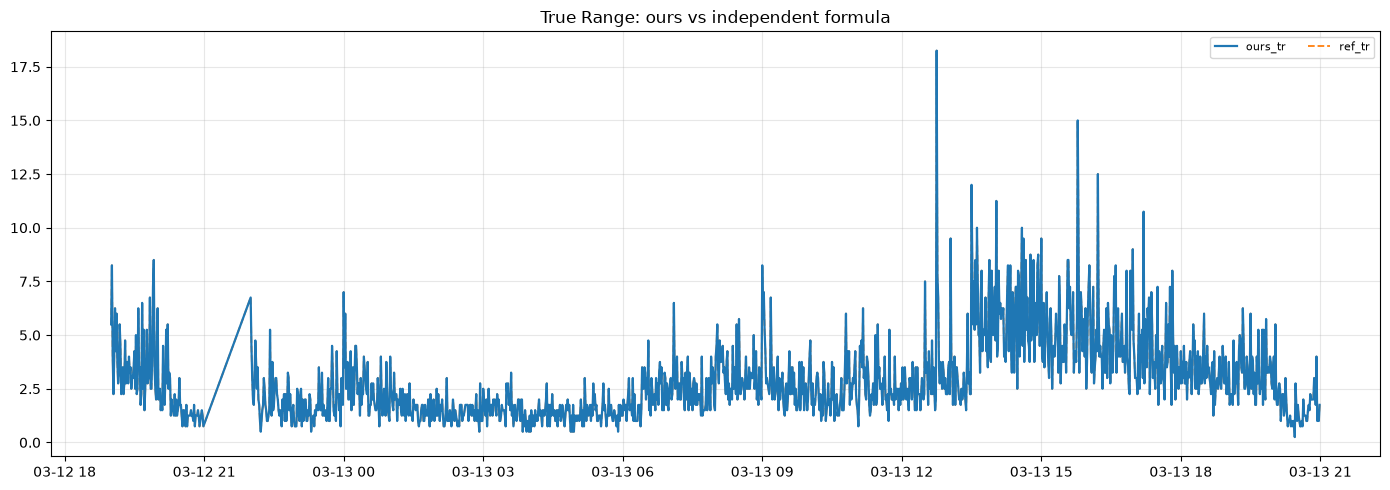

In [12]:
# True Range -- ta doesn't expose this standalone (it's bundled inside
# AverageTrueRange), so the reference here is an independent recomputation
# of the textbook formula rather than a ta library call.
ours_tr = true_range(ohlc)
prev_close = ohlc["close"].shift(1)
ref_tr = pd.concat([ohlc["high"] - ohlc["low"], (ohlc["high"] - prev_close).abs(), (ohlc["low"] - prev_close).abs()], axis=1).max(axis=1)

plot_compare("True Range: ours vs independent formula", ours_tr=ours_tr, ref_tr=ref_tr)

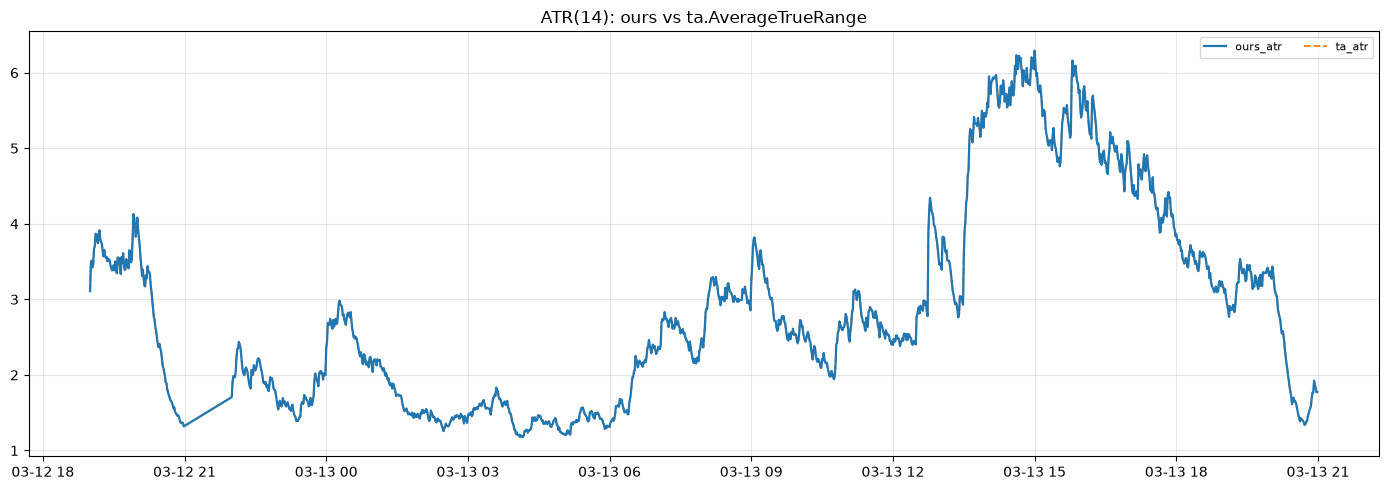

In [13]:
# ATR(14) -- ta seeds Wilder's recursion with a plain SMA of the first 14
# true-range values; ours seeds the ewm recursion from bar 0. Both are
# textbook-valid, and converge -- expect a visible gap on the far left of
# the window that closes up as the lines move right.
ours_atr = atr(ohlc, period=14)
ta_atr = AverageTrueRange(high=ohlc["high"], low=ohlc["low"], close=ohlc["close"], window=14).average_true_range()

plot_compare("ATR(14): ours vs ta.AverageTrueRange", ours_atr=ours_atr, ta_atr=ta_atr)

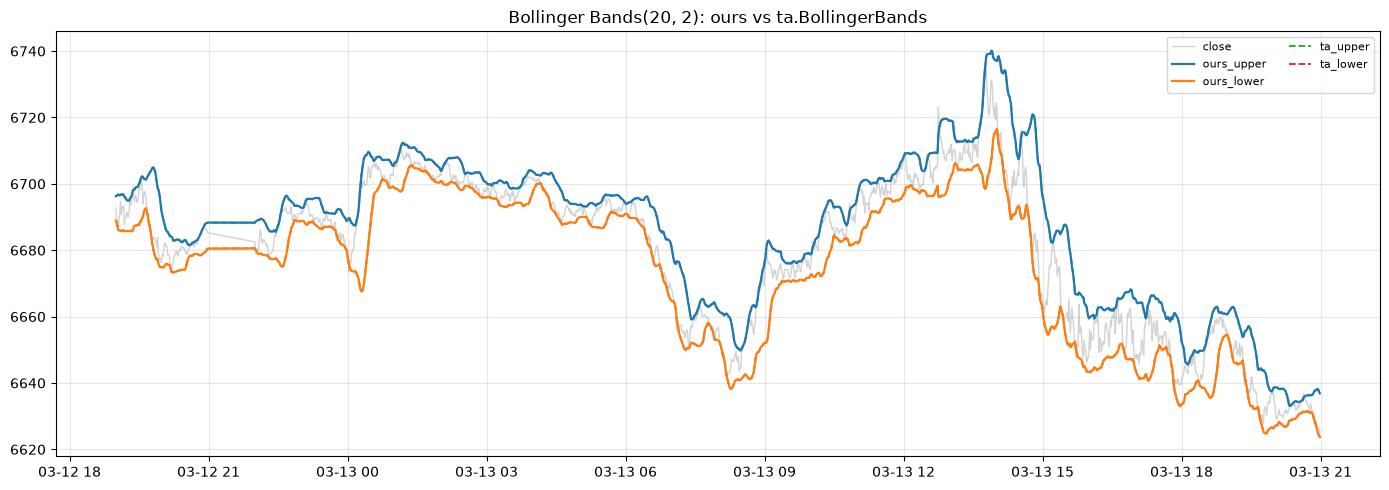

In [14]:
# Bollinger Bands (20, 2 std)
ours_bb = bollinger_bands(ohlc["close"], period=20, standard_deviations=2.0)
ta_bb = BollingerBands(ohlc["close"], window=20, window_dev=2)

plot_compare(
    "Bollinger Bands(20, 2): ours vs ta.BollingerBands",
    price=ohlc["close"],
    ours_upper=ours_bb["upper"],
    ours_lower=ours_bb["lower"],
    ta_upper=ta_bb.bollinger_hband(),
    ta_lower=ta_bb.bollinger_lband(),
)

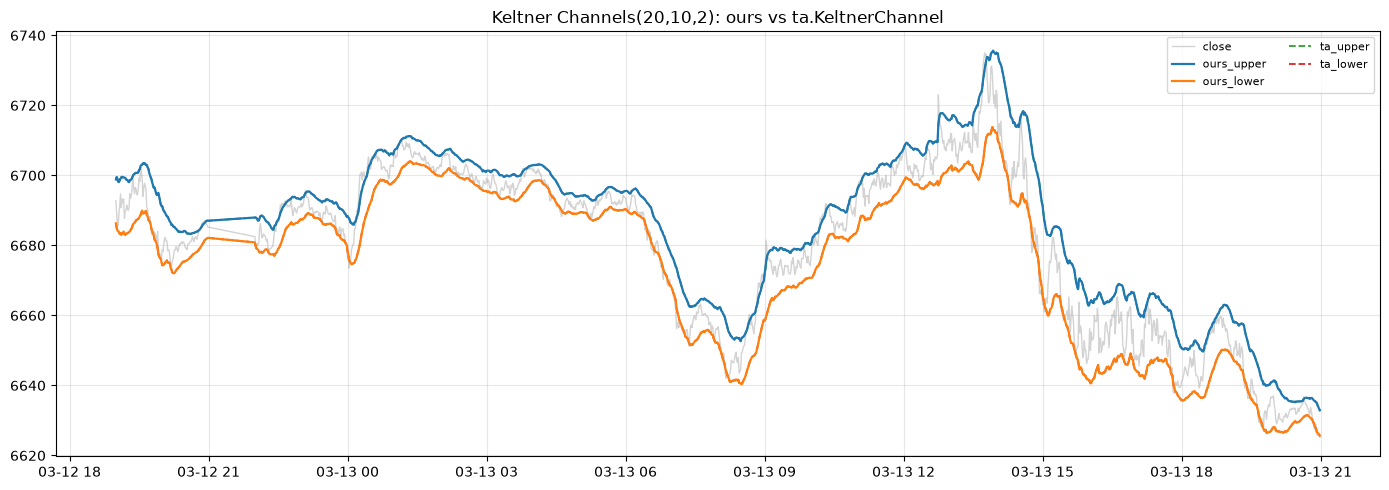

In [15]:
# Keltner Channels (ema=20, atr=10, mult=2) -- centerline is a plain EMA
# (exact match expected); the bands inherit ATR's Wilder-seed convergence.
ours_kc = keltner_channels(ohlc, ema_period=20, atr_period=10, multiplier=2.0)
ta_kc = KeltnerChannel(high=ohlc["high"], low=ohlc["low"], close=ohlc["close"], window=20, window_atr=10, original_version=False, multiplier=2)

plot_compare(
    "Keltner Channels(20,10,2): ours vs ta.KeltnerChannel",
    price=ohlc["close"],
    ours_upper=ours_kc["upper"],
    ours_lower=ours_kc["lower"],
    ta_upper=ta_kc.keltner_channel_hband(),
    ta_lower=ta_kc.keltner_channel_lband(),
)

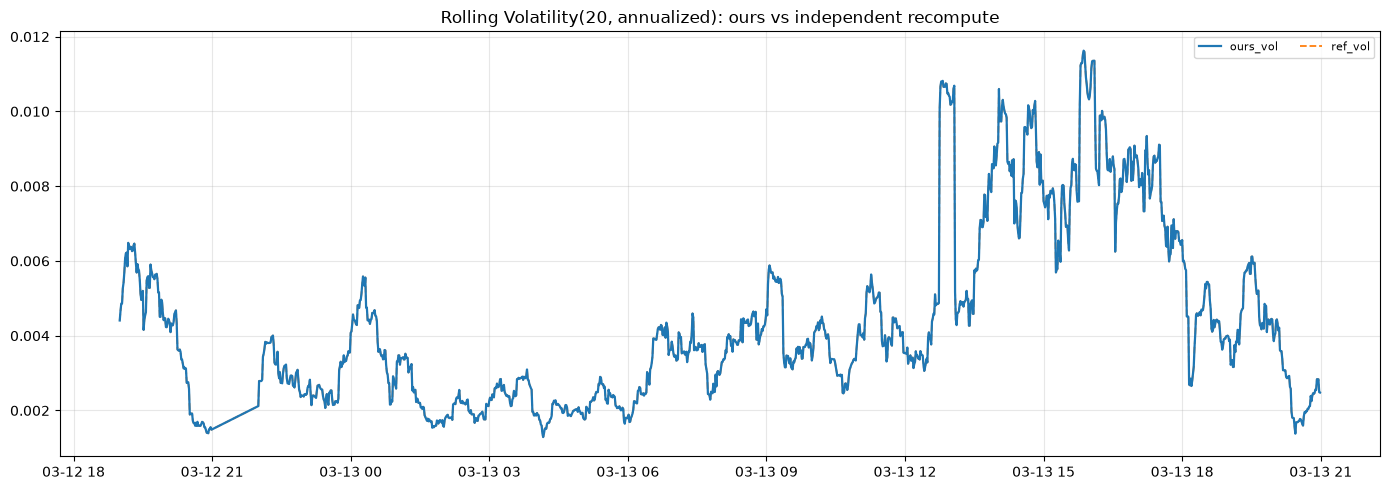

In [16]:
# Rolling (annualized) volatility(20) -- ta has no equivalent; reference is
# an independent recompute of the same textbook formula.
ours_vol = rolling_volatility(ohlc["close"], period=20, annualization_factor=252)
ref_vol = ohlc["close"].pct_change(fill_method=None).rolling(20, min_periods=20).std(ddof=1) * np.sqrt(252)

plot_compare("Rolling Volatility(20, annualized): ours vs independent recompute", ours_vol=ours_vol, ref_vol=ref_vol)

## Trend & channels

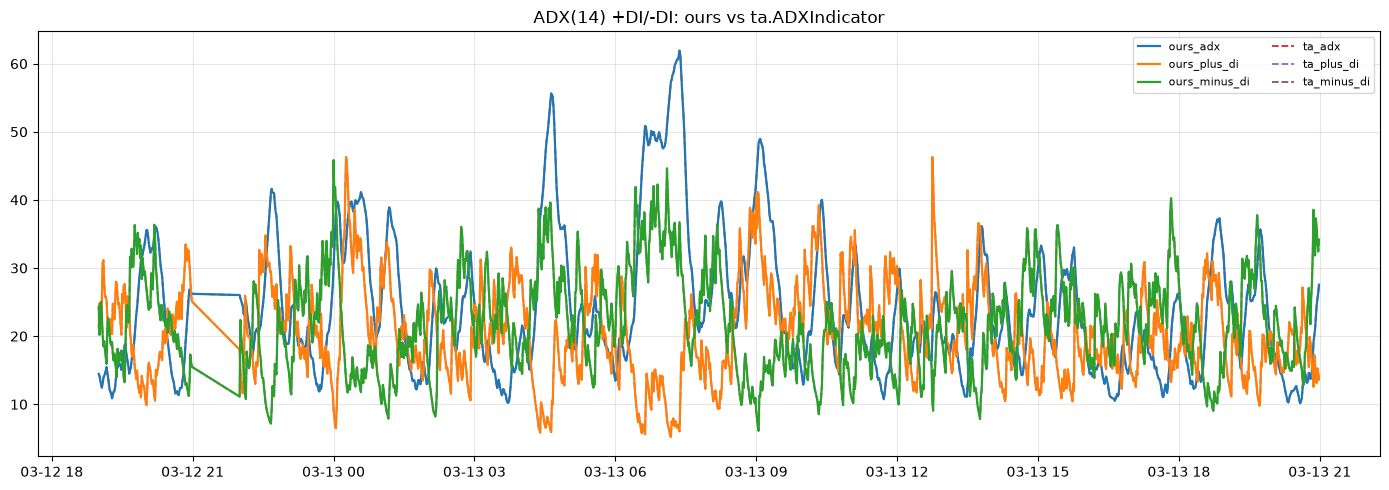

In [17]:
# ADX(14) with +DI/-DI -- same Wilder-seed convergence story as ATR/RSI,
# compounded across two smoothing stages, so allow a bit more room on the left.
ours_adx = adx(ohlc, period=14)
ta_adx_indicator = ADXIndicator(high=ohlc["high"], low=ohlc["low"], close=ohlc["close"], window=14)

plot_compare(
    "ADX(14) +DI/-DI: ours vs ta.ADXIndicator",
    ours_adx=ours_adx["adx"],
    ours_plus_di=ours_adx["positive_di"],
    ours_minus_di=ours_adx["negative_di"],
    ta_adx=ta_adx_indicator.adx(),
    ta_plus_di=ta_adx_indicator.adx_pos(),
    ta_minus_di=ta_adx_indicator.adx_neg(),
)

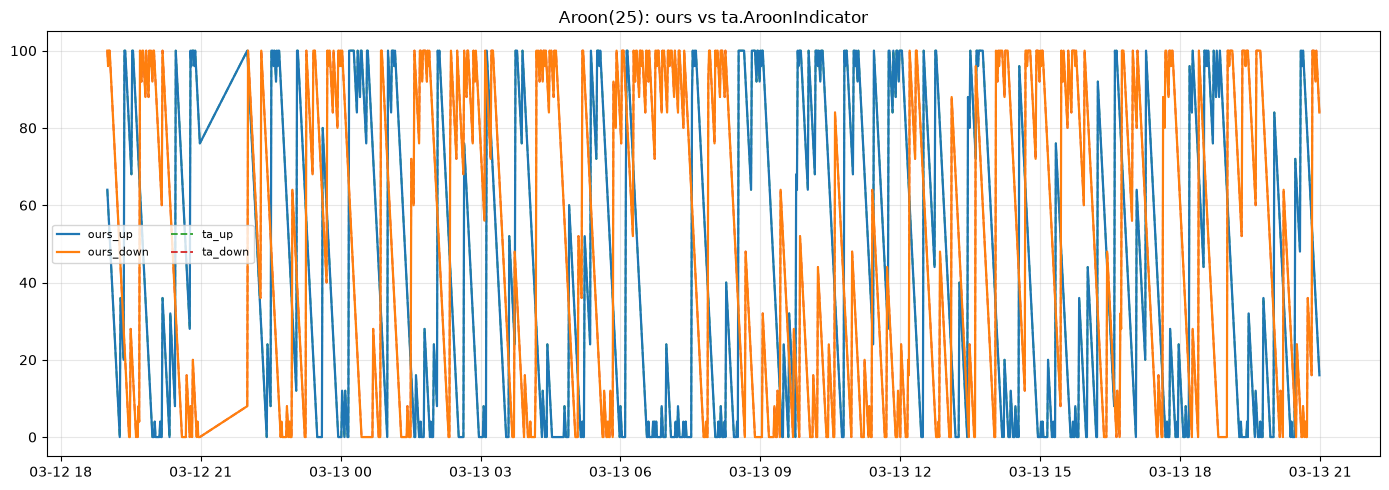

In [18]:
# Aroon(25)
ours_aroon = aroon(ohlc, period=25)
ta_aroon = AroonIndicator(ohlc["high"], ohlc["low"], window=25)

plot_compare(
    "Aroon(25): ours vs ta.AroonIndicator",
    ours_up=ours_aroon["aroon_up"],
    ours_down=ours_aroon["aroon_down"],
    ta_up=ta_aroon.aroon_up(),
    ta_down=ta_aroon.aroon_down(),
)

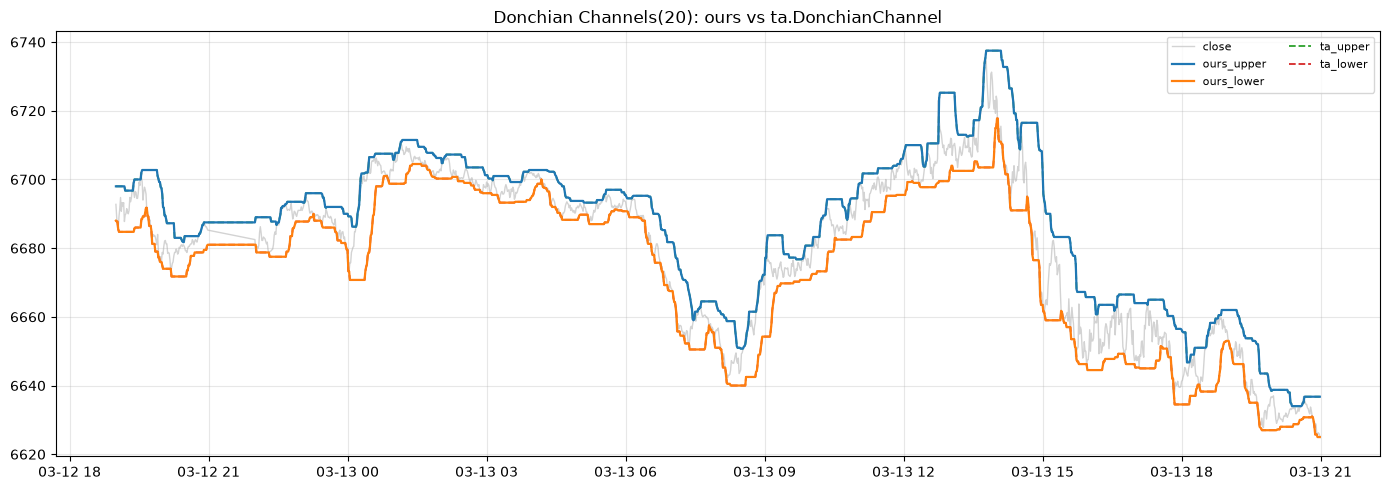

In [19]:
# Donchian Channels(20, shift=1)
ours_dc = donchian_channels(ohlc, period=20, shift=1)
ta_dc = DonchianChannel(high=ohlc["high"], low=ohlc["low"], close=ohlc["close"], window=20, offset=1)

plot_compare(
    "Donchian Channels(20): ours vs ta.DonchianChannel",
    price=ohlc["close"],
    ours_upper=ours_dc["upper"],
    ours_lower=ours_dc["lower"],
    ta_upper=ta_dc.donchian_channel_hband(),
    ta_lower=ta_dc.donchian_channel_lband(),
)

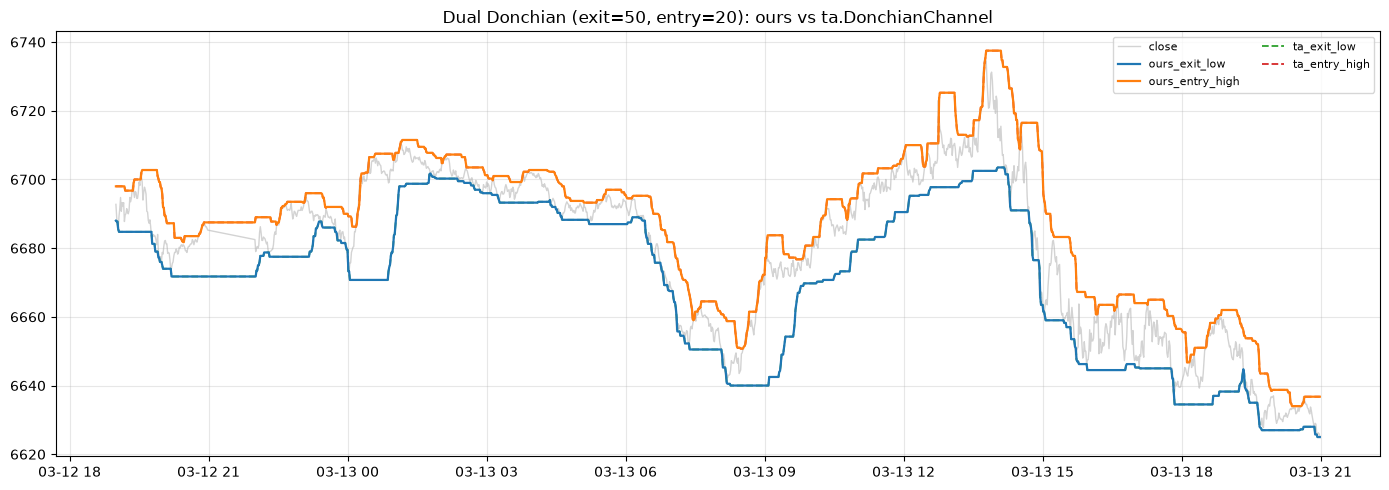

In [20]:
# Dual Donchian Channels (exit=50, entry=20) -- the hysteresis version used
# by the dcemachop futures strategy. Built from two separate ta.DonchianChannel
# calls at the respective periods.
ours_dual = dual_donchian_channels(ohlc, exit_period=50, entry_period=20, shift=1)
ta_exit = DonchianChannel(high=ohlc["high"], low=ohlc["low"], close=ohlc["close"], window=50, offset=1)
ta_entry = DonchianChannel(high=ohlc["high"], low=ohlc["low"], close=ohlc["close"], window=20, offset=1)

plot_compare(
    "Dual Donchian (exit=50, entry=20): ours vs ta.DonchianChannel",
    price=ohlc["close"],
    ours_exit_low=ours_dual["exit_low"],
    ours_entry_high=ours_dual["entry_high"],
    ta_exit_low=ta_exit.donchian_channel_lband(),
    ta_entry_high=ta_entry.donchian_channel_hband(),
)

## No `ta` equivalent -- independent reference implementations

The next few indicators aren't in the `ta` library at all. Each is checked against a small reference implementation written fresh in this notebook (a second, independent read of the public formula -- not copied from `indicators/` or from the old `strategies/futures/indicators.py` duplicate that was removed).

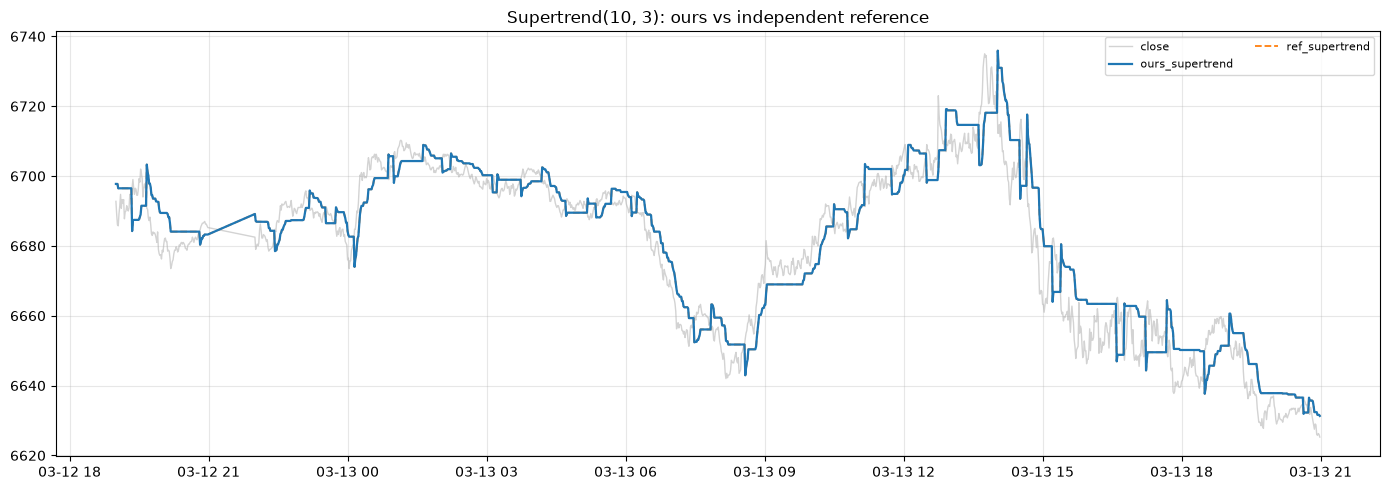

In [21]:
# Supertrend(10, 3) vs an independent reference implementation
def reference_supertrend(data: pd.DataFrame, period: int, multiplier: float) -> pd.DataFrame:
    high, low, close = data["high"], data["low"], data["close"]
    prev_close = close.shift(1)
    tr = pd.concat([high - low, (high - prev_close).abs(), (low - prev_close).abs()], axis=1).max(axis=1)
    average_true_range = tr.ewm(alpha=1.0 / period, adjust=False, min_periods=period).mean()

    mid = (high + low) / 2.0
    upper_basic = mid + multiplier * average_true_range
    lower_basic = mid - multiplier * average_true_range

    n = len(data)
    final_upper, final_lower = np.full(n, np.nan), np.full(n, np.nan)
    direction, line = np.full(n, np.nan), np.full(n, np.nan)

    valid = np.flatnonzero(average_true_range.notna().to_numpy())
    if len(valid) == 0:
        return pd.DataFrame({"supertrend": line, "direction": direction}, index=data.index)

    start = int(valid[0])
    final_upper[start], final_lower[start] = upper_basic.iloc[start], lower_basic.iloc[start]
    direction[start] = 1.0
    line[start] = final_lower[start]

    close_v, upper_v, lower_v = close.to_numpy(), upper_basic.to_numpy(), lower_basic.to_numpy()
    for i in range(start + 1, n):
        final_upper[i] = upper_v[i] if (upper_v[i] < final_upper[i - 1] or close_v[i - 1] > final_upper[i - 1]) else final_upper[i - 1]
        final_lower[i] = lower_v[i] if (lower_v[i] > final_lower[i - 1] or close_v[i - 1] < final_lower[i - 1]) else final_lower[i - 1]
        if direction[i - 1] == -1.0 and close_v[i] > final_upper[i]:
            direction[i] = 1.0
        elif direction[i - 1] == 1.0 and close_v[i] < final_lower[i]:
            direction[i] = -1.0
        else:
            direction[i] = direction[i - 1]
        line[i] = final_lower[i] if direction[i] == 1.0 else final_upper[i]

    return pd.DataFrame({"supertrend": line, "direction": direction}, index=data.index)

ours_st = supertrend(ohlc, period=10, multiplier=3.0)
ref_st = reference_supertrend(ohlc, period=10, multiplier=3.0)

plot_compare("Supertrend(10, 3): ours vs independent reference", price=ohlc["close"], ours_supertrend=ours_st["supertrend"], ref_supertrend=ref_st["supertrend"])

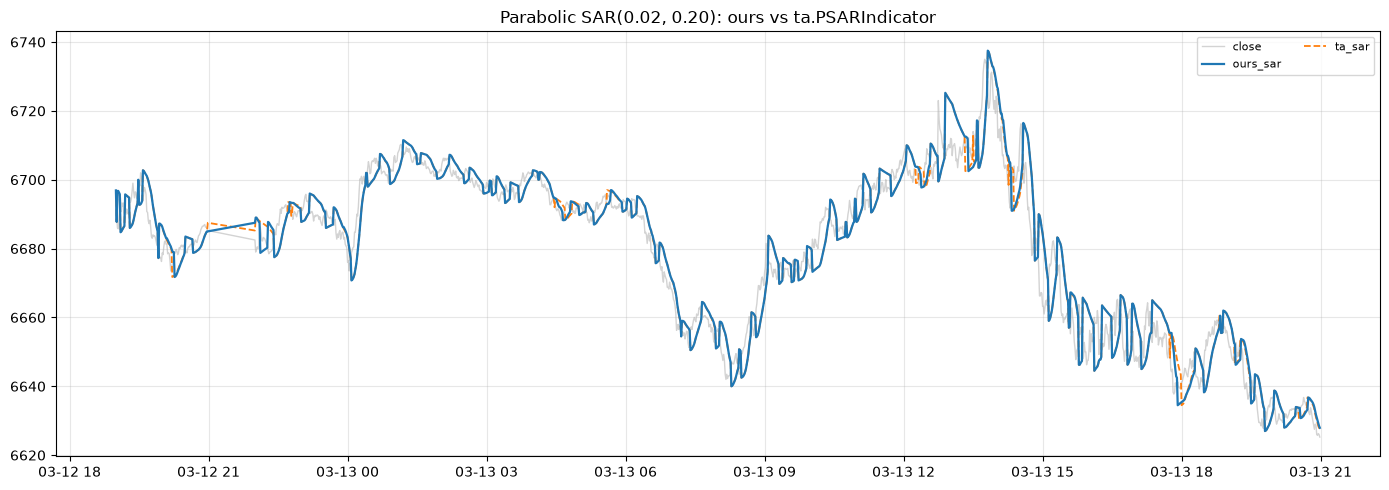

In [22]:
# Parabolic SAR (step=0.02, max=0.20) -- ta DOES provide this, but PSAR
# implementations vary in tie-break handling at reversal bars, so expect
# the occasional single-bar disagreement rather than a perfect overlay.
ours_psar = parabolic_sar(ohlc, step=0.02, max_step=0.20)
ta_psar = PSARIndicator(high=ohlc["high"], low=ohlc["low"], close=ohlc["close"], step=0.02, max_step=0.20)
ta_psar_combined = ta_psar.psar_up().combine_first(ta_psar.psar_down())

plot_compare("Parabolic SAR(0.02, 0.20): ours vs ta.PSARIndicator", price=ohlc["close"], ours_sar=ours_psar["sar"], ta_sar=ta_psar_combined)

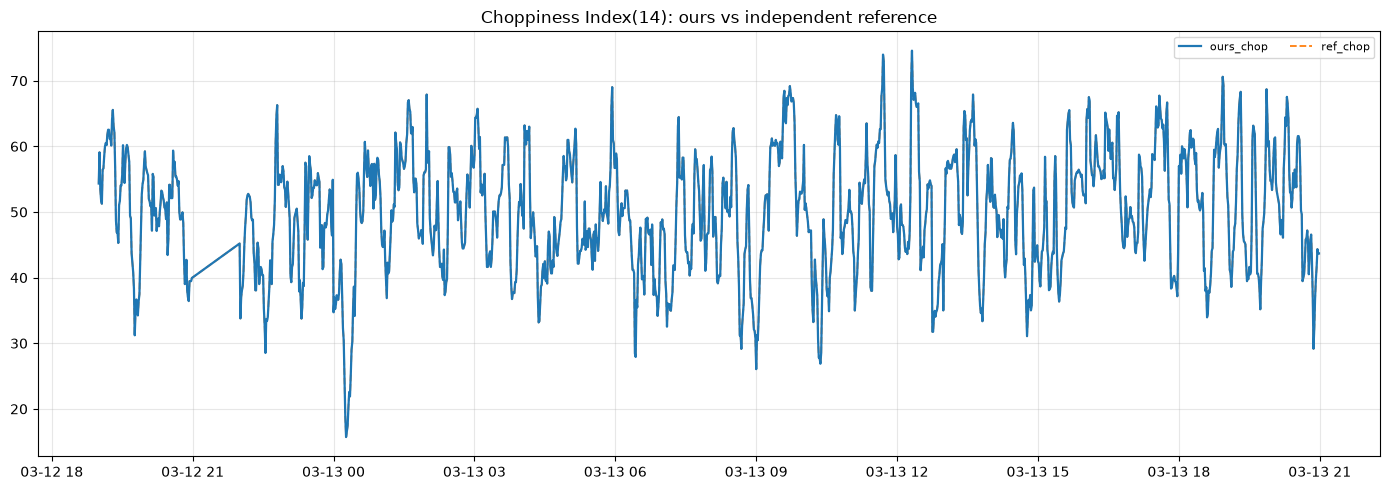

In [23]:
# Choppiness Index(14) vs an independent reference implementation
ours_chop = choppiness_index(ohlc, period=14)
prev_close = ohlc["close"].shift(1)
ref_tr_chop = pd.concat([ohlc["high"] - ohlc["low"], (ohlc["high"] - prev_close).abs(), (ohlc["low"] - prev_close).abs()], axis=1).max(axis=1)
ref_chop = 100.0 * np.log10(ref_tr_chop.rolling(14).sum() / (ohlc["high"].rolling(14).max() - ohlc["low"].rolling(14).min())) / np.log10(14.0)

plot_compare("Choppiness Index(14): ours vs independent reference", ours_chop=ours_chop, ref_chop=ref_chop)

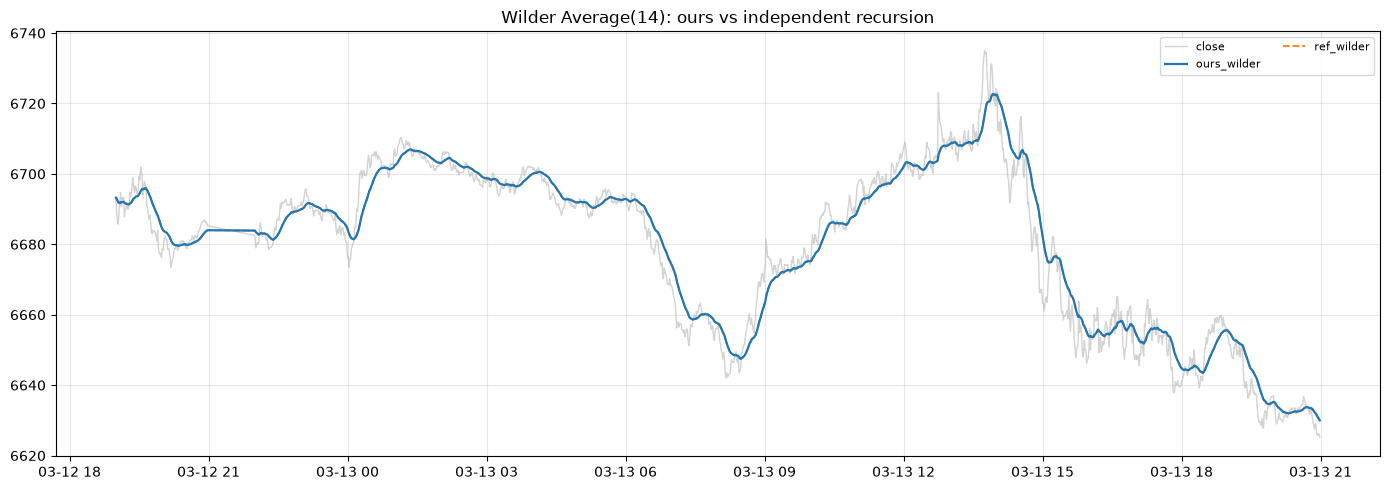

In [24]:
# Wilder average(14) vs an independent, from-scratch recursion (not the
# ewm-based implementation used by indicators/ itself)
ours_wilder = wilder_average(ohlc["close"], period=14)

close_values = ohlc["close"].to_numpy(dtype=float)
ref_wilder_values = np.full(len(close_values), np.nan)
alpha = 1.0 / 14
ref_wilder_values[0] = close_values[0]
for i in range(1, len(close_values)):
    ref_wilder_values[i] = alpha * close_values[i] + (1.0 - alpha) * ref_wilder_values[i - 1]
ref_wilder = pd.Series(ref_wilder_values, index=ohlc.index)

plot_compare("Wilder Average(14): ours vs independent recursion", price=ohlc["close"], ours_wilder=ours_wilder, ref_wilder=ref_wilder)

## Simple derived helpers (price_action.py)

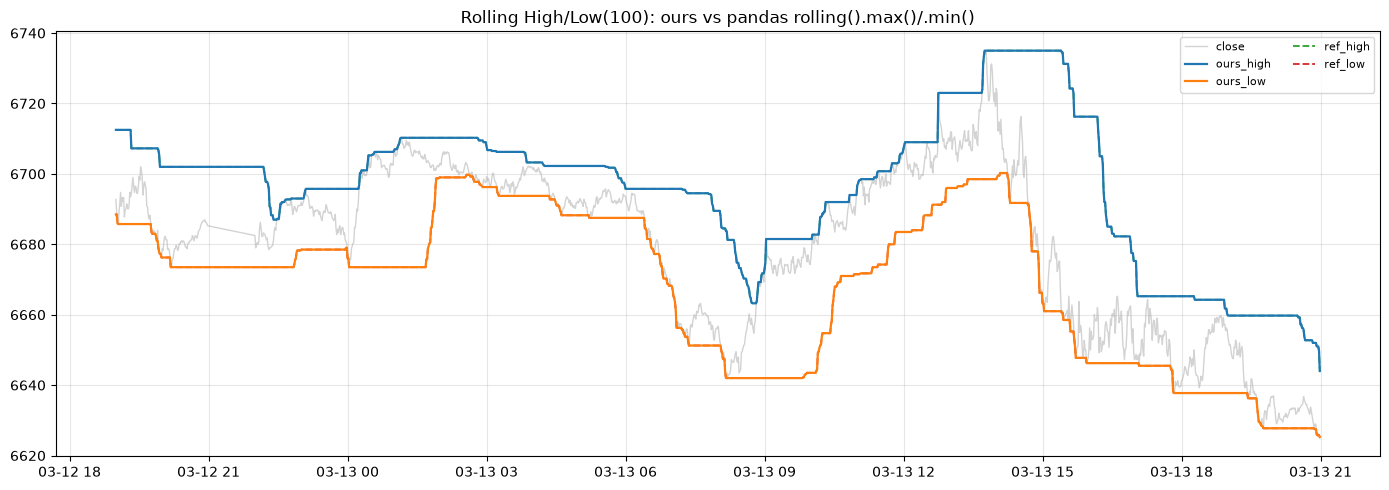

In [25]:
# Rolling high / rolling low (100) vs plain pandas rolling().max()/.min()
ours_high = rolling_high(ohlc["close"], period=100)
ours_low = rolling_low(ohlc["close"], period=100)
ref_high = ohlc["close"].rolling(100, min_periods=100).max()
ref_low = ohlc["close"].rolling(100, min_periods=100).min()

plot_compare(
    "Rolling High/Low(100): ours vs pandas rolling().max()/.min()",
    price=ohlc["close"],
    ours_high=ours_high, ours_low=ours_low,
    ref_high=ref_high, ref_low=ref_low,
)

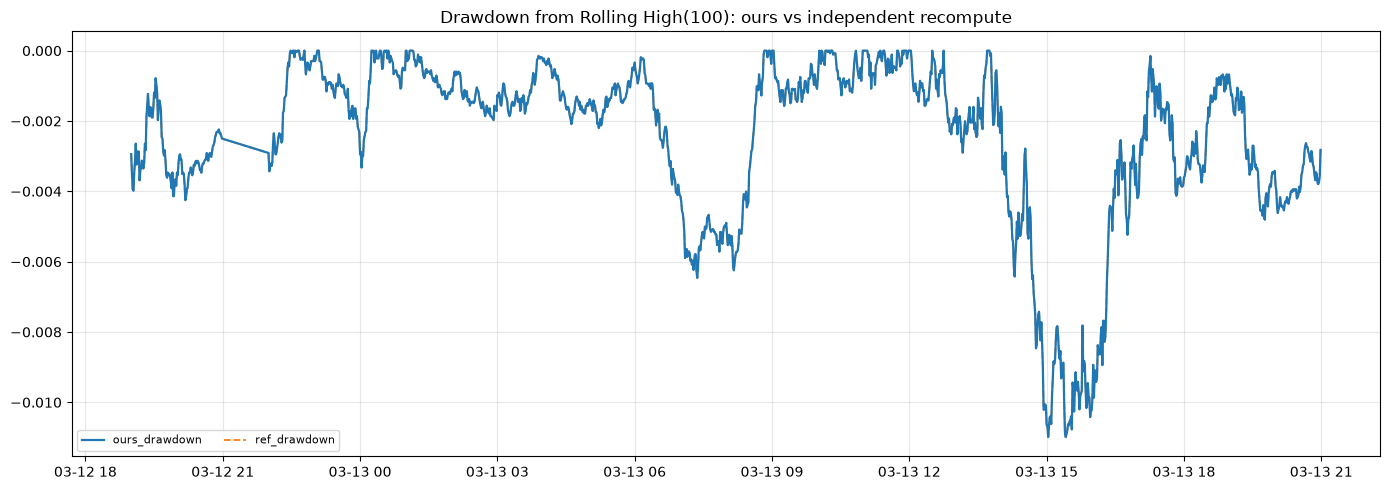

In [26]:
# Drawdown from rolling high(100) vs independent recompute
ours_dd = drawdown_from_rolling_high(ohlc["close"], period=100, min_periods=1)
ref_high_dd = ohlc["close"].rolling(100, min_periods=1).max()
ref_dd = ohlc["close"] / ref_high_dd - 1.0

plot_compare("Drawdown from Rolling High(100): ours vs independent recompute", ours_drawdown=ours_dd["drawdown"], ref_drawdown=ref_dd)

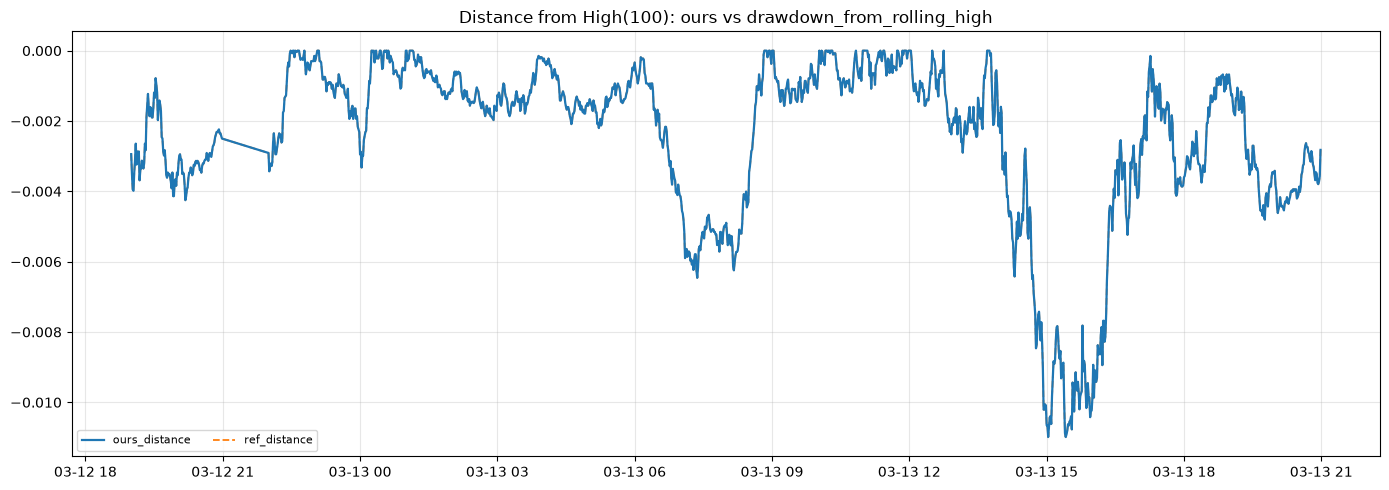

In [27]:
# Distance from high(100) -- this is defined as the same quantity as
# drawdown_from_rolling_high, so the "reference" here is that function
# itself rather than a third independent formula.
ours_dfh = distance_from_high(ohlc["close"], period=100)
ref_dfh = drawdown_from_rolling_high(ohlc["close"], period=100, min_periods=1)["drawdown"]

plot_compare("Distance from High(100): ours vs drawdown_from_rolling_high", ours_distance=ours_dfh, ref_distance=ref_dfh)

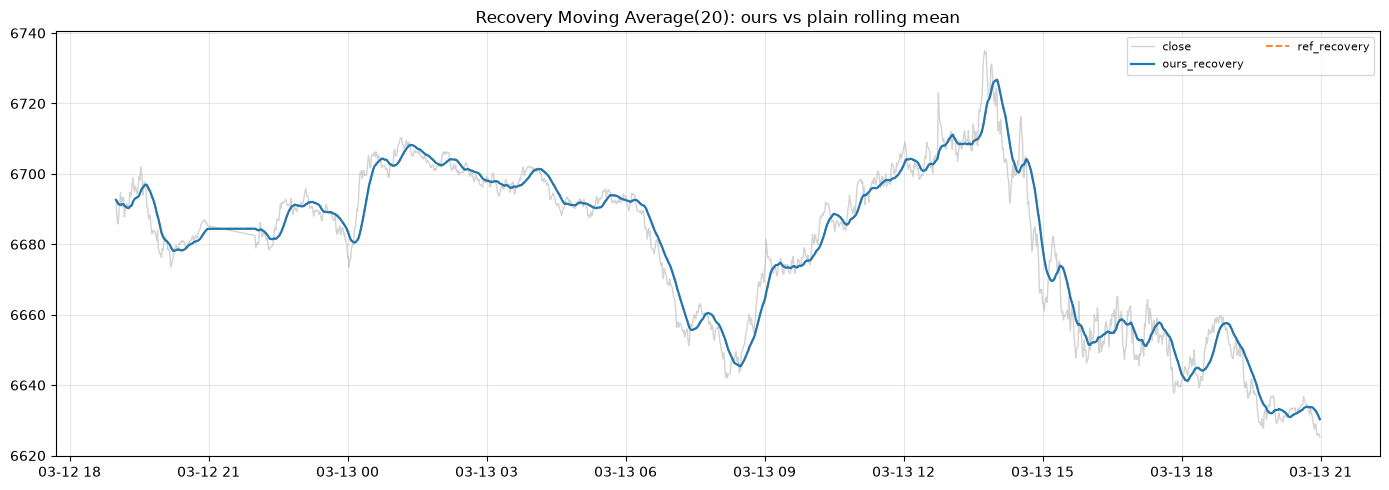

In [28]:
# Recovery moving average(20) -- this is just an sma() alias, so the
# reference is a plain pandas rolling mean at the same period.
ours_recovery = recovery_moving_average(ohlc["close"], period=20)
ref_recovery = ohlc["close"].rolling(20, min_periods=20).mean()

plot_compare("Recovery Moving Average(20): ours vs plain rolling mean", price=ohlc["close"], ours_recovery=ours_recovery, ref_recovery=ref_recovery)